# Prototyping Impulsive SIP Functions

In [85]:
# Imports:
# %load_ext autoreload
# %autoreload 2

import os 
import sys 
import numpy as np 
import matplotlib.pyplot as plt

def find_root_path(path:str, word:str):
    parts = path.split(word, 1)
    if len(parts) > 1:
        return parts[0] + word
    else:
        return path

root_folder = find_root_path(os.getcwd(), 'Code')
sys.path.append(root_folder)

from util_dyn import * 
from impulsiveSIP import *
from Run_Code import params
from Trajectory_Selection.Trajectory_Candidates import trajectory_candidates

# === Define Constants ===
# Earth parameters
J2 = 0.001082635819197
R_E = 6.3781363e+06    # Earth radius [m]
mu_E = 3.986004415e+14 # Earth gravitational parameter [m^3/s^2]


# === Initial conditions ===
oe_chief_0 = np.array([params.a_chief*1e3, params.e_chief, params.i_chief, params.raan_chief, params.w_chief, params.M_chief])


# === Time settings ===
t0_sec = 0
tf_sec = params.T_single_orbit*4

# === Get Initial and Final QNS ROEs ===
# Call the generate candidates function
roe_candidates = trajectory_candidates()
# For now define the first ROE as the initial orbit
roe0 = roe_candidates[-1]
roe0 = roe0*params.a_chief*1e3
# For now define the second ROE as the final orbit:
roef = roe_candidates[-2]
roef = roef*params.a_chief*1e3

# SHIRT Case:
# roe0 = np.array([0, -8, 0, 0, 0, 0])
# roef = np.array([-0.250, -8.1732, 0.0257, -0.1476, -0.030, 0.1724])

# Hardcode cases:
roe0 = np.array([0, 57, 10, 10, 20, 20])*1
roef = np.array([0, 40, 10, 10, 20, 20])*1

# === Use ROE-based propagation with QNS ROEs ===
# Define lambda-functions - STMs as a function of time
B = lambda t: cim_roe(propagate_oe(oe_chief_0, t - t0_sec, mu_E, J2), mu_E)
Φ = lambda t2, t1: stm_roe(propagate_oe(oe_chief_0, t1 - t0_sec, mu_E, J2), t2 - t1, mu_E, R_E, J2)
Γ = lambda t: Φ(tf_sec, t) @ B(t)

nx = roe0.size
assert Φ(tf_sec, t0_sec).shape == (nx, nx), f"Φ shape is {Φ(tf_sec, t0_sec).shape}, expected {(nx,nx)}"
assert B(t0_sec).shape == (nx, 3),          f"B shape is {B(t0_sec).shape}, expected {(nx,3)}"
assert Γ(t0_sec).shape == (nx, 3),           f"Γ shape is {Γ(t0_sec).shape}, expected {(nx,3)}"


# === Run SIP ===
SIP = impulsiveSIP(Φ, Γ, roe0, roef, t0_sec, tf_sec)
topt, uopt, λopt = SIP.solve()

# === Filter and print ===
# epsilon = 1e-5
# mask = np.linalg.norm(uopt, axis=1) > epsilon
# topt = topt[mask]
# uopt = uopt[mask].T

print("solved!")
print("optimal burn times (sec): ", topt)
print("optimal delta-Vs (RTN): ", uopt)
print("total cost (magnitude sum): ", np.sum(np.linalg.norm(uopt, axis=0)))


Iteration 0: max gU = 3.178599402503668
Iteration 1: max gU = 1.2953345185865488
Iteration 2: max gU = 1.0634066864183598
Iteration 3: max gU = 1.0161057079370737
Iteration 4: max gU = 1.0036891266534858
solved!
optimal burn times (sec):  [ 1350.82474804  1399.06848904  1471.43410054  4366.05856062
  4390.18043112  4414.30230162  4438.42417212 22650.43640011
 22698.68014111 22771.04575261]
optimal delta-Vs (RTN):  [[ 2.69267127e-06  4.08000114e-05 -4.67590044e-05]
 [ 8.02772953e-08  1.29087281e-06 -1.49394577e-06]
 [ 3.07179518e-08  5.44566838e-07 -6.36037534e-07]
 [ 1.36406312e-06  1.83750140e-05  2.10681601e-05]
 [ 3.21709435e-06  4.20502849e-05  4.84983966e-05]
 [ 9.27664805e-06  1.17732037e-04  1.36516182e-04]
 [ 6.09479653e-06  7.51513097e-05  8.75649294e-05]
 [ 1.28860247e-05 -1.37566522e-04  1.60045168e-04]
 [ 2.57460809e-06 -2.65788013e-05  3.05448614e-05]
 [ 1.33584135e-05 -1.31781839e-04  1.47880697e-04]]
total cost (magnitude sum):  0.0005500597504141076


# Plotting Control History:

Text(0.5, 1.0, 'Koenig Impulsive SIP Control History')

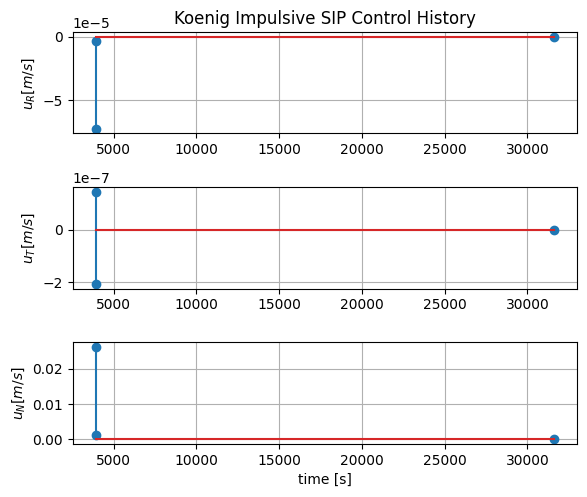

In [36]:
period = 2*np.pi*np.sqrt(params.a_chief**3/mu_E)
n = np.sqrt(mu_E/params.a_chief**3)

topt_ = np.hstack((topt, tf_sec))
uopt_ = np.concatenate((uopt, np.zeros((3, 1))), axis=1)  # add zero control at the end
fig = plt.figure(figsize=(6, 5))
ax1 = fig.add_subplot(311)
ax1.stem(topt_/period, uopt_[0,:], label='$u_R$')
ax1.grid()
ax1.set_ylabel('$u_R [m/s]$')
ax2 = fig.add_subplot(312)
ax2.stem(topt_/period, uopt_[1,:], label='$u_T$')
ax2.grid()
ax2.set_ylabel('$u_T [m/s]$')
ax3 = fig.add_subplot(313)
ax3.stem(topt_/period, uopt_[2,:], label='$u_N$')
ax3.grid()
ax3.set_ylabel('$u_N [m/s]$')
ax3.set_xlabel('time [s]')
plt.tight_layout()
ax1.set_title('Koenig Impulsive SIP Control History')


# Plotting Setup

In [37]:
aroe_hist = np.zeros((6, 2*len(topt)+1))
aroe_hist[:,0] = roe0

t_prev = 0.0
oe_k = oe_chief_0.copy()

eta   = np.sqrt(1 - oe_chief_0[1]**2)
kappa = 3/4 * J2*R_E**2*np.sqrt(mu_E) / (oe_chief_0[0]**(7/2)*eta**4)
P = 3*np.cos(oe_chief_0[2])**2 - 1
Q = 5*np.cos(oe_chief_0[2])**2 - 1
RAAN_dot = -2*np.cos(oe_chief_0[2])*kappa
aop_dot = kappa * Q
M_dot = n + kappa*eta*P

for idx, t_burn in enumerate(topt):
    dt = t_burn - t_prev
    
    col_prev = 2*idx
    col_prop = col_prev + 1
    col_imp = col_prev + 2

    aroe_hist[:,col_prop] = Φ(t_burn, t_prev) @ aroe_hist[:,col_prev]
    oe_k[3] += RAAN_dot * dt 
    oe_k[4] += aop_dot * dt 
    oe_k[5] += M_dot * dt
    aroe_hist[:,col_imp] = aroe_hist[:,col_prop] + B(t_burn) @ uopt[:,idx]
    t_prev = t_burn

tvec = np.concatenate(([0.0], np.repeat(topt, 2)))

oec_hist = propagate_oe(oe_chief_0, tvec, mu_E, J2)
dx = eroe_to_rtn(aroe_hist, oec_hist)
tvec

print(np.shape(dx), np.shape(uopt), np.shape(tvec)) 

(6, 5) (3, 2) (5,)


# Plotting RTN Position Changes:

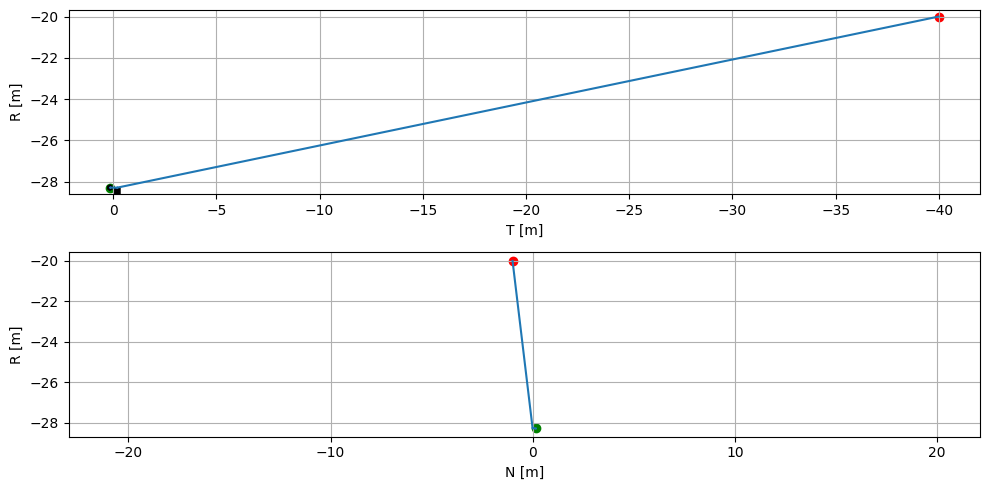

In [38]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(211)
ax1.scatter(dx[1,0], dx[0,0], color='r')
ax1.scatter(dx[1,-1], dx[0,-1], color='g')
ax1.plot(dx[1,:], dx[0,:])
ax1.quiver(dx[1,1::2], dx[0,1::2], -uopt[1,:], uopt[0,:])
ax1.set_xlabel('T [m]')
ax1.set_ylabel('R [m]')
ax1.grid()
ax1.invert_xaxis()
ax1.axis('equal')
ax2 = fig.add_subplot(212)  
ax2.scatter(dx[2,0], dx[0,0], color='r')
ax2.scatter(dx[2,-1], dx[0,-1], color='g')
ax2.plot(dx[2,:], dx[0,:])
ax2.set_xlabel('N [m]')
ax2.set_ylabel('R [m]')
ax2.grid()
ax2.axis('equal')
fig.tight_layout()


# Plotting ROE changes

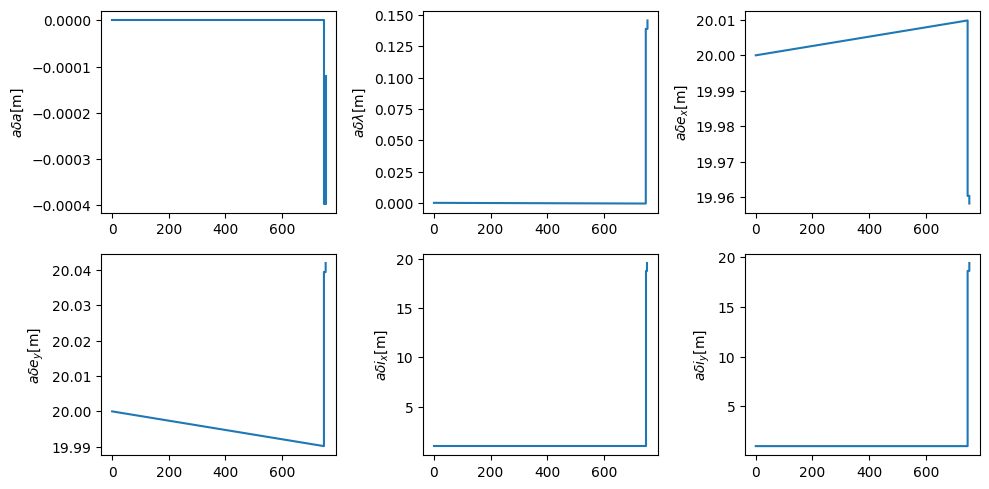

In [39]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(231)
ax1.plot(tvec, aroe_hist[0,:])
ax1.set_ylabel('$a\delta a$[m]')
ax2 = fig.add_subplot(232)
ax2.plot(tvec, aroe_hist[1,:])
ax2.set_ylabel('$a\delta \lambda$[m]')
ax3 = fig.add_subplot(233)
ax3.plot(tvec, aroe_hist[2,:])
ax3.set_ylabel('$a\delta e_x$[m]')
ax4 = fig.add_subplot(234)
ax4.plot(tvec, aroe_hist[3,:])
ax4.set_ylabel('$a\delta e_y$[m]')
ax5 = fig.add_subplot(235)
ax5.plot(tvec, aroe_hist[4,:])
ax5.set_ylabel('$a\delta i_x$[m]')
ax6 = fig.add_subplot(236)
ax6.plot(tvec, aroe_hist[5,:])
ax6.set_ylabel('$a\delta i_y$[m]')
fig.tight_layout()



In [40]:
import cvxpy as cp
print(cp.installed_solvers())


import mosek
print("MOSEK license loaded successfully!")


['CLARABEL', 'MOSEK', 'OSQP', 'SCIPY', 'SCS']
MOSEK license loaded successfully!


# Run all candidates and compute delta-V costs

In [41]:
import os 
import sys 
import numpy as np 
import matplotlib.pyplot as plt

def find_root_path(path:str, word:str):
    parts = path.split(word, 1)
    return parts[0] + word if len(parts) > 1 else path

root_folder = find_root_path(os.getcwd(), 'Code')
sys.path.append(root_folder)

from util_dyn import * 
from impulsiveSIP import *
from Run_Code import params
from Trajectory_Selection.Trajectory_Candidates import trajectory_candidates

# === Constants ===
J2 = 0.001082635819197
R_E = 6.3781363e+06    
mu_E = 3.986004415e+14 

# === Initial conditions ===
oe_chief_0 = np.array([
    params.a_chief * 1e3, params.e_chief, params.i_chief, 
    params.raan_chief, params.w_chief, params.M_chief
])
t0_sec = 0
tf_sec = params.T_single_orbit

# === Get Initial and Final QNS ROEs (dimensionalize) ===
roe_candidates = trajectory_candidates()
roe0 = roe_candidates[0] * params.a_chief * 1e3  # fixed initial state

# === Results container ===
results = []

# === Loop over all other candidate targets ===
for i in range(1, len(roe_candidates)):
    roef = roe_candidates[i] * params.a_chief * 1e3

    # Define time-dependent functions
    B = lambda t: cim_roe(propagate_oe(oe_chief_0, t - t0_sec, mu_E, J2), mu_E)
    Φ = lambda t2, t1: stm_roe(propagate_oe(oe_chief_0, t1 - t0_sec, mu_E, J2), t2 - t1, mu_E, R_E, J2)
    Γ = lambda t: Φ(tf_sec, t) @ B(t)

    # Check matrix shapes
    nx = roe0.size
    assert Φ(tf_sec, t0_sec).shape == (nx, nx), f"[{i}] Φ shape is {Φ(tf_sec, t0_sec).shape}, expected {(nx,nx)}"
    assert B(t0_sec).shape == (nx, 3),          f"[{i}] B shape is {B(t0_sec).shape}, expected {(nx,3)}"
    assert Γ(t0_sec).shape == (nx, 3),          f"[{i}] Γ shape is {Γ(t0_sec).shape}, expected {(nx,3)}"

    # Solve SIP
    try:
        SIP = impulsiveSIP(Φ, Γ, roe0, roef, t0_sec, tf_sec)
        topt, uopt, λopt = SIP.solve()

        # Filter small impulses
        epsilon = 1e-3
        mask = np.linalg.norm(uopt, axis=1) > epsilon
        uopt = uopt[mask].T
        topt = topt[mask]

        # Compute total cost
        total_dv = np.sum(np.linalg.norm(uopt, axis=0))
        results.append((i, total_dv))
        print(f"[{i}] Success: ∆V = {total_dv:.6f} m/s")
    except Exception as e:
        results.append((i, np.inf))
        print(f"[{i}] Failure: {e}")

# === Print summary table ===
print("\n=== SIP ∆V Results (x0 = candidate 0) ===")
print(f"{'Target idx':<12}{'Total ∆V (m/s)':>16}")
print("-" * 28)
for idx, cost in results:
    status = f"{cost:.6f}" if np.isfinite(cost) else "FAILED"
    print(f"{idx:<12}{status:>16}")


Iteration 0: max gU = 1.027163859324479
Iteration 1: max gU = 1.00729462423098
Iteration 2: max gU = 1.0017299991024293
Iteration 3: max gU = 1.0003953718964
Iteration 4: max gU = 1.000078997957593
Iteration 5: max gU = 1.0000197708848002
[1] Success: ∆V = 0.027289 m/s
Iteration 0: max gU = 1.0969115694823137
Iteration 1: max gU = 1.003568213691906
Iteration 2: max gU = 1.0008568096271333
Iteration 3: max gU = 1.000102715513349
[2] Success: ∆V = 0.044133 m/s
Iteration 0: max gU = 1.0271721405070269
Iteration 1: max gU = 1.0074260602504816
Iteration 2: max gU = 1.001731110671658
Iteration 3: max gU = 1.000395596091341
Iteration 4: max gU = 1.0000790991893234
Iteration 5: max gU = 1.0000197664621835
[3] Success: ∆V = 0.071805 m/s
Iteration 0: max gU = 1.1031071184378392
Iteration 1: max gU = 1.0183566603699405
Iteration 2: max gU = 1.0046838905358992
Iteration 3: max gU = 1.0010938580580415
Iteration 4: max gU = 1.0000328355163064
Iteration 5: max gU = 1.0000040427328256
[4] Success: ∆V 

In [42]:

# === Print summary table ===
print("\n=== SIP ∆V Results (x0 = candidate 0) ===")
print(f"{'Target idx':<12}{'Total ∆V (m/s)':>16}")
print("-" * 28)
for idx, cost in results:
    status = f"{cost:.6f}" if np.isfinite(cost) else "FAILED"
    print(f"{idx:<12}{status:>16}")


=== SIP ∆V Results (x0 = candidate 0) ===
Target idx    Total ∆V (m/s)
----------------------------
1                   0.027289
2                   0.044133
3                   0.071805
4                   0.082770
5                   0.115892
6                   0.125125
7                     FAILED
